# ER1: No-Communication Control

Multi-agent coordination emerges from two sources: **what agents learn** and **what agents share**.
Before measuring the value of communication, we need to isolate the first factor — how well can agents learn to coordinate through observation alone?

This notebook trains agents on the Discovery K-N convergence task with **zero communication channels**.
The result is a performance floor: any communication protocol (ER2–E1) that fails to beat this floor adds complexity without benefit.

> **Research question:** Under partial observability and no message passing, how much of the rendezvous task can MARL policies solve through individual learning alone?

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent.parent.parent
RENDEZVOUS_ROOT = REPO_ROOT / "rendezvous_comm"
sys.path.insert(0, str(RENDEZVOUS_ROOT))

In [2]:
import torch
import matplotlib.pyplot as plt

from src.config import load_experiment
from src.storage import ExperimentStorage
from src.runner import run_sweep, evaluate_with_vmas, make_heuristic_policy_fn
from src.display import (
    display_config, display_sweep_summary,
    display_environment_info, scrollable_md, display_metric_cards, display_verdict,
    display_config_selector,
    display_baseline_comparison, display_results_dashboard,
    display_training_videos, display_artifact_tree,
    display_figure,
)
from src.plotting import (
    plot_sweep_heatmap, plot_seed_variance, plot_training_dashboard,
    plot_baseline_grouped_bars, plot_results_comparison,
    plot_sweep_overview, save_figure,
)

print(f"Torch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

Torch: 2.10.0  |  CUDA: False


In [3]:
# ── Available configs with freshness status ──
display_config_selector("er1")

#,Config,Algo,N agents,LiDAR,Runs,Complete,Freshness
1,demo.yaml,MAPPO,4-8,0.35,2,2/2,VALID
2,single_mappo_n4_l035.yaml,MAPPO,4,0.35,1,0/1,NEW
3,sweep_mappo-ippo_n2-6_l025-045.yaml,"MAPPO, IPPO",4-8,0.25-0.45,54,2/54,CONFIG CHANGED


## Configuration

Select a config from the dropdown above. Each YAML is self-contained — filename encodes what's inside:
- `single_*` → 1 run for quick validation (~15 min on CPU)
- `sweep_*` → full parameter sweep (hours/days)

Freshness badges: **VALID** = results match current config+code, **CONFIG/CODE CHANGED** = results are stale, **NEW** = no results yet.

The cell below loads the selected config and displays environment dimensions.

In [ ]:
# ── Select config here ──
# Pick from the table above. Change the filename to switch configs.
#CONFIG_FILE_NAME = "single_mappo_n4_l035.yaml"
#CONFIG_FILE_NAME = "sweep_mappo-ippo_n2-6_l025-045.yaml"
CONFIG_FILE_NAME = "demo.yaml"

CONFIG = RENDEZVOUS_ROOT / "configs" / "er1" / CONFIG_FILE_NAME
FORCE_RETRAIN = False  # Set True to re-run even if results exist

spec = load_experiment(CONFIG)
spec.ensure_dirs()

display_environment_info(spec)

In [5]:
display_config(spec)

## Measurement Strategy

We evaluate along three axes relevant to the no-comm baseline:

| Category | Metric | Computation | Interpretation |
|----------|--------|-------------|----------------|
| **Task** | M1 Success Rate | `mean(targets_covered_total ≥ N_targets)` | Fraction of episodes where **all** targets were covered (not time-truncated) |
| | M2 Avg Return | `mean(Σ_t Σ_i r_i,t)` | Cumulative reward per episode, summed across agents and steps (covering − collisions − time) |
| | M3 Avg Steps | `mean(done_step)`, `max_steps` if incomplete | Steps until all targets covered; lower = faster |
| | M6 Coverage Progress | `mean(min(covered, N_targets) / N_targets)` | Partial credit: fraction of targets covered by episode end |
| **Safety** | M4 Collisions/Ep | `mean(Σ_t Σ_i 𝟙[collision_rew_i,t < 0])` | Count of agent-agent collision events per episode |
| **Coordination** | M8 Agent Utilization | `mean(std(c_i) / mean(c_i))` where `c_i` = agent *i*'s covering count | CV of per-agent covering contributions; 0 = perfectly balanced |
| | M9 Spatial Spread | `mean(1/T Σ_t mean_pairs ‖pos_i − pos_j‖)` | Mean pairwise agent distance averaged over time; higher = exploring |

**M5 (Tokens)** is always 0 here — it becomes meaningful in ER2+.
**M7 (Sample Efficiency)** = training frames to reach 80% of final eval reward (computed post-hoc from BenchMARL CSVs).

### Reference baselines
Before training, we measure two non-learned policies to calibrate expectations:

ID,Metric,Heuristic,Random
M1,Success Rate,8.5%,0.0%
M2,Avg Return,-8.16,-7.85
M3,Avg Steps,192.5,200.0
M4,Collisions/Episode,80.93,1.97
M6,Coverage Progress,61.2%,2.5%
M9,Spatial Spread,0.714,1.089

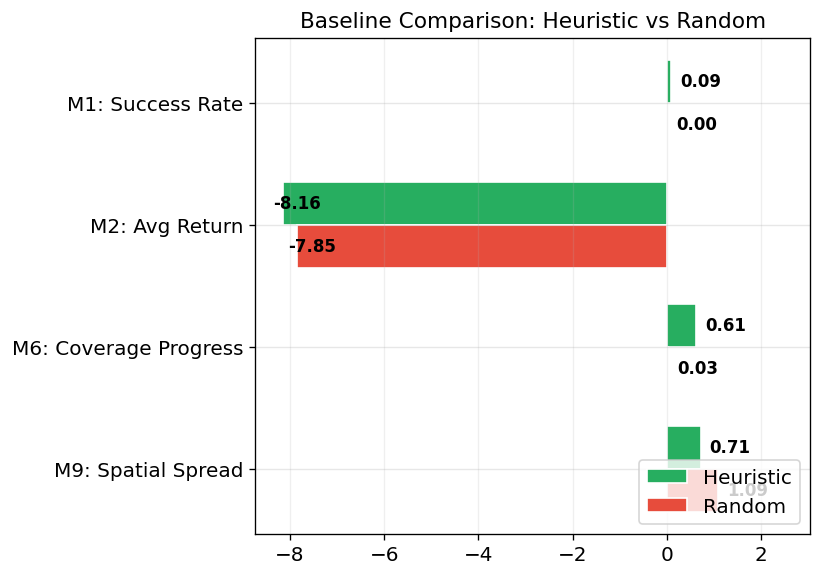

In [6]:
SANITY_OVERRIDES = {
    "n_agents": 4, "n_targets": 7, "agents_per_target": 2,
    "targets_respawn": False,
}

heuristic_fn = make_heuristic_policy_fn()
heuristic_metrics = evaluate_with_vmas(
    spec.task, task_overrides=SANITY_OVERRIDES,
    policy_fn=heuristic_fn, n_eval_episodes=200, n_envs=200,
)

random_metrics = evaluate_with_vmas(
    spec.task, task_overrides=SANITY_OVERRIDES,
    policy_fn=None, n_eval_episodes=200, n_envs=200,
)

# Grouped bar chart + comparison table side-by-side
fig = plot_baseline_grouped_bars(heuristic_metrics, random_metrics)
display_baseline_comparison(heuristic_metrics, random_metrics, fig=fig)

## Training

Each run: freeze config → train with BenchMARL (MAPPO/IPPO) → save policy → evaluate → save metrics + report.
Set `skip_complete=True` to resume interrupted sweeps without re-running finished runs.

In [7]:
results = run_sweep(spec, skip_complete=not FORCE_RETRAIN)

ER1 sweep:   0%|          | 0/1 [00:00<?, ]

  er1_mappo_n4_t4_k2_l035_s0:   0%|          | 0/100 [00:00<?]

2026-03-12 14:42:36.818 Python[68568:15384047] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/qf/45hpwykd6s58js26xgtbw3tm0000gn/T/org.python.python.savedState


## Training Curves

BenchMARL logs scalar metrics at each iteration. The 3×2 dashboard shows six training signals:

| Panel | BenchMARL scalar | What it measures | What to look for |
|-------|-----------------|------------------|------------------|
| **Eval Reward** | `eval_reward_episode_reward_mean` | M2 during eval: `Σ_t Σ_i r_i,t` averaged over eval episodes | Upward trend; dashed line = heuristic baseline |
| **Targets Covered** | `collection_agents_info_targets_covered` | Per-step target covering events during collection | Should increase as agents learn the objective |
| **Covering Reward** | `collection_agents_info_covering_reward` | Reward component from covering: `covering_rew_coeff × 𝟙[K agents in range]` | Increasing = agents learn to converge on targets |
| **Collision Penalty** | `collection_agents_info_collision_rew` | Penalty signal: `agent_collision_penalty × 𝟙[dist < min_collision_dist]` | Should trend toward 0 (fewer collisions) |
| **Eval Episode Length** | `eval_reward_episode_len_mean` | Mean steps per eval episode (capped at `max_steps`) | Decreasing = agents complete the task faster |
| **Policy Entropy** | `train_agents_entropy` | Shannon entropy of the policy action distribution | Should decrease gradually; collapse to 0 = bad |


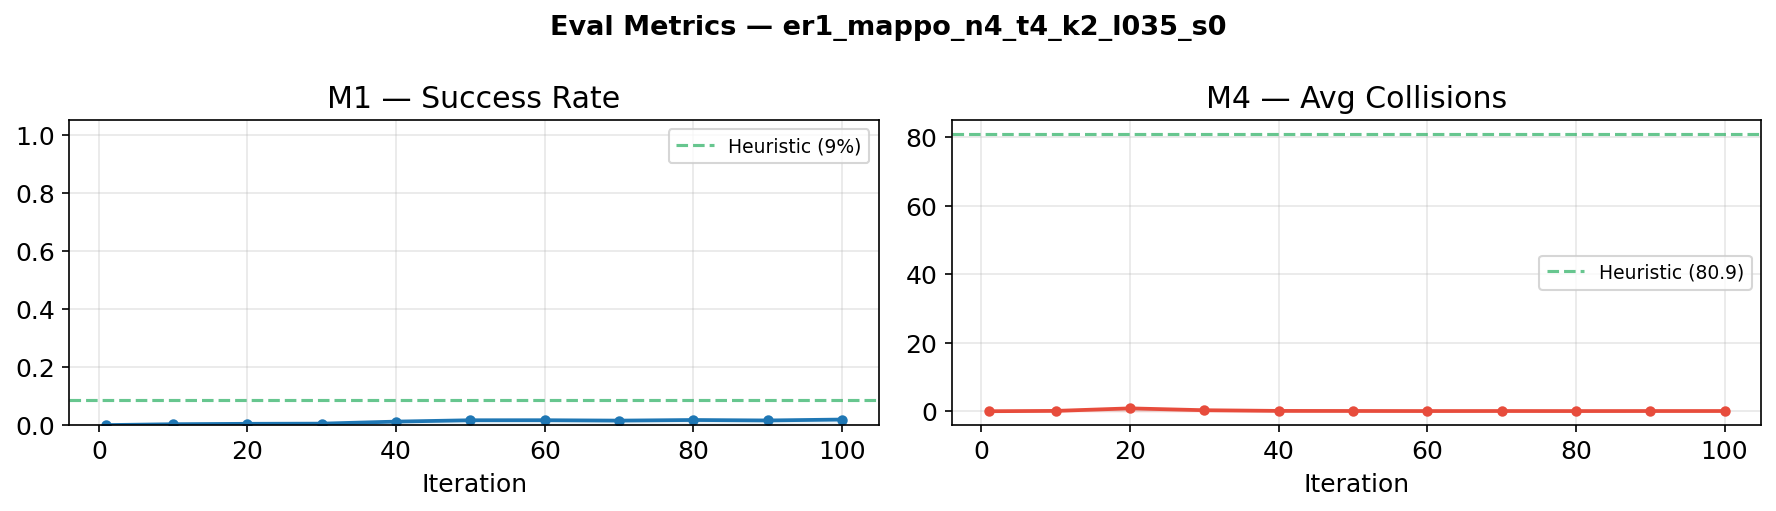


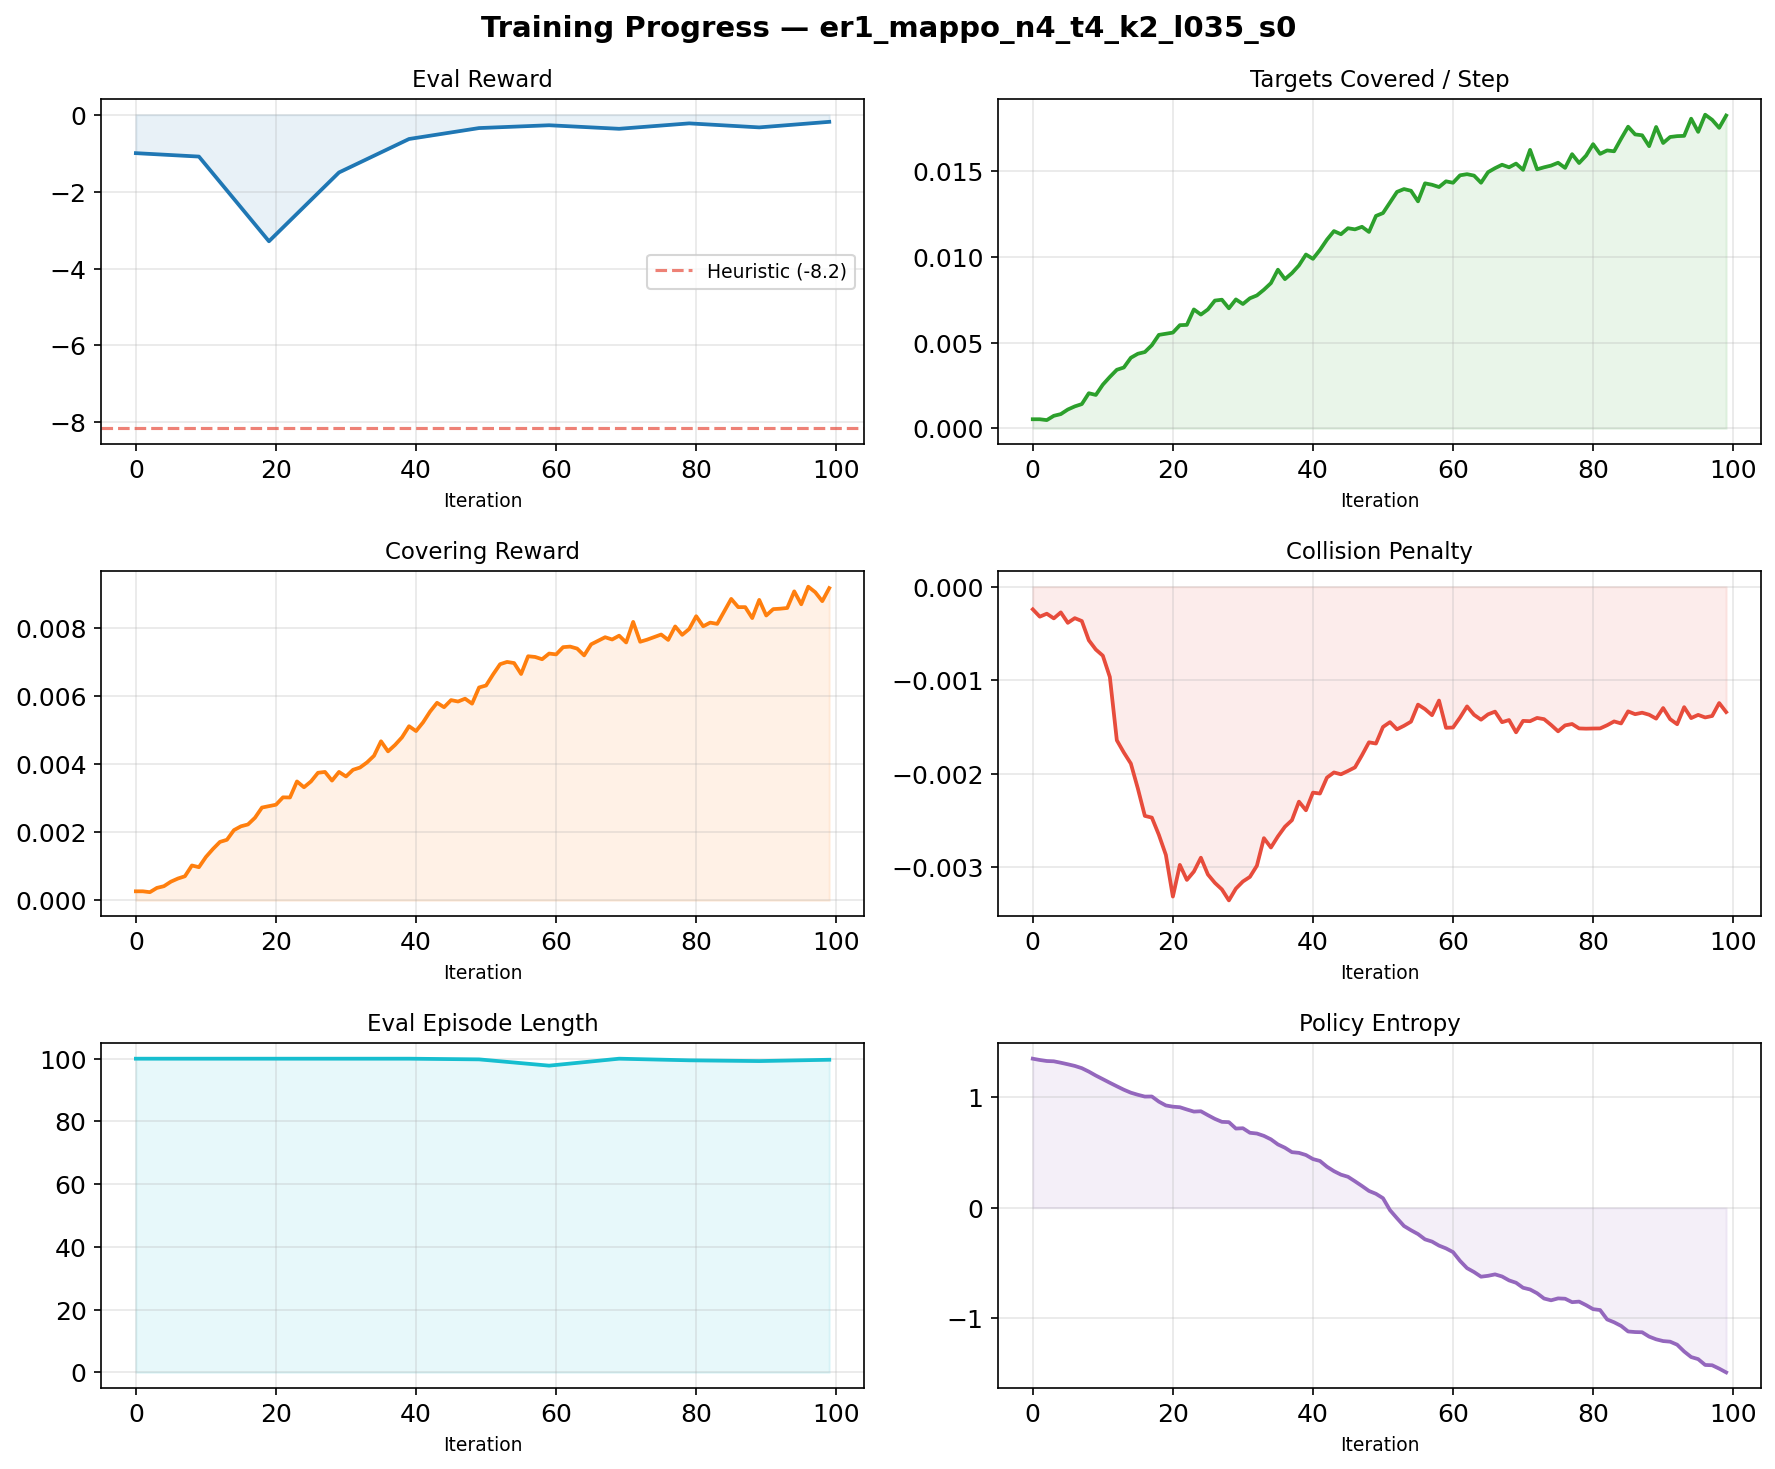

In [8]:
from IPython.display import clear_output
clear_output(wait=True)

storage = ExperimentStorage(spec.exp_id)

# Only show runs from the current sweep
all_metrics = {k: v for k, v in storage.load_all_metrics().items() if k in results}

if not all_metrics:
    print("No completed runs yet. Run the training cell first.")
else:
    from src.plotting import set_style
    for run_id in sorted(all_metrics.keys()):
        rs = storage.get_run(run_id)
        scalars = rs.load_benchmarl_scalars()
        if not scalars:
            print(f"No BenchMARL scalars found for {run_id}.")
            continue
        m1_data = scalars.get("eval_M1_success_rate")
        m4_data = scalars.get("eval_M4_avg_collisions")
        if m1_data or m4_data:
            set_style()
            fig_m, (ax1, ax4) = plt.subplots(1, 2, figsize=(12, 3.5))
            if m1_data:
                s, v = zip(*m1_data)
                ax1.plot(s, v, color="#1f77b4", linewidth=1.8, marker="o", markersize=4)
                ax1.fill_between(s, v, alpha=0.1, color="#1f77b4")
                h = heuristic_metrics.get("M1_success_rate")
                if h is not None:
                    ax1.axhline(y=h, color="#27ae60", ls="--", lw=1.5, alpha=0.7, label=f"Heuristic ({h:.0%})")
                    ax1.legend(fontsize=9)
            ax1.set_ylim(0, 1.05); ax1.set_title("M1 — Success Rate"); ax1.set_xlabel("Iteration"); ax1.grid(True, alpha=0.3)
            if m4_data:
                s, v = zip(*m4_data)
                ax4.plot(s, v, color="#e74c3c", linewidth=1.8, marker="o", markersize=4)
                ax4.fill_between(s, v, alpha=0.1, color="#e74c3c")
                h = heuristic_metrics.get("M4_avg_collisions")
                if h is not None:
                    ax4.axhline(y=h, color="#27ae60", ls="--", lw=1.5, alpha=0.7, label=f"Heuristic ({h:.1f})")
                    ax4.legend(fontsize=9)
            ax4.set_title("M4 — Avg Collisions"); ax4.set_xlabel("Iteration"); ax4.grid(True, alpha=0.3)
            fig_m.suptitle(f"Eval Metrics — {run_id}", fontsize=13, fontweight="bold")
            fig_m.tight_layout()
            save_figure(fig_m, str(rs.output_dir / "m1_m4_training.png"))
            display_figure(fig_m)
        fig = plot_training_dashboard(scalars, title=f"Training Progress — {run_id}", heuristic_reward=heuristic_metrics.get("M2_avg_return"))
        save_figure(fig, str(rs.output_dir / "training_dashboard.png"))
        display_figure(fig)

In [9]:
from IPython.display import clear_output
clear_output(wait=True)

# Videos are only available for the FIRST run in a sweep.
# Pyglet's display singleton goes stale after the first window close
# (known bug: pyglet#953), so rendering is auto-disabled for subsequent
# runs to avoid crashes. To get videos for a specific config, run it
# as a single_* config or place it first in the sweep.
if all_metrics:
    first_run_id = sorted(all_metrics.keys())[0]
    rs = storage.get_run(first_run_id)
    display_training_videos(rs)

## Results


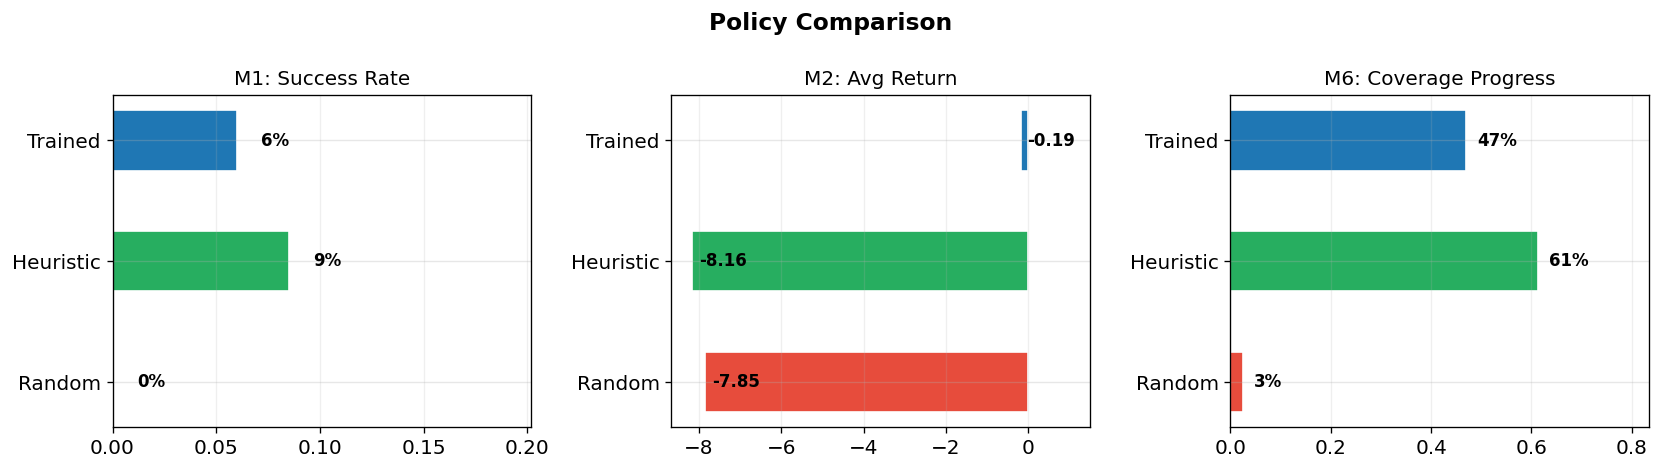

In [10]:
from IPython.display import clear_output
clear_output(wait=True)

if not all_metrics:
    print("No completed runs yet.")
else:
    for run_id in sorted(all_metrics.keys()):
        trained_metrics = all_metrics[run_id]
        run_storage = storage.get_run(run_id)
        comparison = {"Random": random_metrics, "Heuristic": heuristic_metrics, "Trained": trained_metrics}
        fig = plot_results_comparison(comparison)
        save_figure(fig, str(run_storage.output_dir / "results_comparison.png"))
        display_results_dashboard(trained_metrics, comparison_fig=fig, run_id=run_id)

## Sweep Analysis

With a `sweep_*` config, we can compare success across agent counts, LiDAR ranges, and algorithms.
If you used a `single_*` config, this section will be skipped (only 1 run).

In [11]:
from IPython.display import clear_output
clear_output(wait=True)

if all_metrics and len(all_metrics) > 1:
    df = storage.to_dataframe()
    if not df.empty:
        # M1 Success rate heatmap across configs
        if "n_agents" in df.columns and len(df["n_agents"].unique()) > 1:
            fig = plot_sweep_heatmap(
                df, metric="M1_success_rate",
                row_param="n_agents", col_param="lidar_range",
                title="ER1: M1 Success Rate (N agents × LiDAR range)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_success_heatmap.png"))
            display_figure(fig)

            # M4 Collisions heatmap
            fig = plot_sweep_heatmap(
                df, metric="M4_avg_collisions",
                row_param="n_agents", col_param="lidar_range",
                title="ER1: M4 Collisions (N agents × LiDAR range)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_collisions_heatmap.png"))
            display_figure(fig)

        # Algorithm comparison
        if "algorithm" in df.columns and len(df["algorithm"].unique()) > 1:
            fig = plot_seed_variance(
                df, metric="M1_success_rate", group_by="algorithm",
                title="ER1: MAPPO vs IPPO — M1 Success Rate (across seeds)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_algo_comparison.png"))
            display_figure(fig)
else:
    print("Sweep analysis requires multiple runs. Use a sweep config and re-run.")

Sweep analysis requires multiple runs. Use a sweep config and re-run.


## Interpretation

The scatter plots below show metric relationships across all runs. Key questions:

| Plot | Axes | What to look for |
|------|------|-----------------|
| **Safety tradeoff** | M1 vs M4 | Do high-success runs also have high collisions? If so, agents brute-force coverage by crowding. |
| **Speed** | M1 vs M3 | Are successful runs also fast? M3 ≈ max_steps means agents barely finish in time. |
| **Balance** | M6 vs M8 | High coverage with low utilization CV = agents share work. High CV = some agents idle. |
| **Exploration** | M1 vs M9 | Does spatial spread help or hurt? Communication should improve this tradeoff. |

In [12]:
from IPython.display import clear_output
clear_output(wait=True)

if all_metrics:
    df = storage.to_dataframe()

    # ── Multi-metric overview scatter (all runs) ──
    if not df.empty and len(all_metrics) > 1:
        fig = plot_sweep_overview(df, title="ER1: Metric Relationships (all runs)")
        save_figure(fig, str(spec.results_dir / "sweep_metric_overview.png"))
        display_figure(fig)

    # ── Verdict ──
    if not df.empty:
        if "n_agents" in df.columns and 4 in df["n_agents"].values:
            sub = df[df["n_agents"] == 4]
        else:
            sub = df
        display_verdict(
            sub["M1_success_rate"].mean(),
            sub["M2_avg_return"].mean(),
        )

    # ── Cross-run observations ──
    if len(all_metrics) > 1 and not df.empty:
        notes = []
        mean_sr = df["M1_success_rate"].mean()
        mean_coll = df["M4_avg_collisions"].mean()
        mean_cov = df["M6_coverage_progress"].mean()
        mean_util = df["M8_agent_utilization"].mean()
        if mean_sr > 0.8 and mean_coll > 10:
            notes.append(
                "High average M1 but also high M4 — agents crowd "
                "targets to achieve coverage, causing collisions."
            )
        if mean_sr < 0.3 and mean_cov > 0.5:
            notes.append(
                "Low M1 but decent M6 — agents cover most targets "
                "but fail on the last few. Communication could help."
            )
        if mean_util > 0.8:
            notes.append(
                "High M8 across runs — unbalanced workload. "
                "Some agents idle while others do the covering."
            )
        if mean_sr > 0.5 and mean_coll < 5:
            notes.append(
                "Good M1 with low M4 — agents solve the task "
                "without excessive collisions."
            )
        if notes:
            print("Cross-run observations:")
            print("\n".join(f"  → {n}" for n in notes))

## Report & Run Details

The sweep report below aggregates all runs (config, metrics, best/worst).
Use the dropdown to inspect individual run reports with full training stats and artifacts.

# Sweep Report: ER1 — No-Comm Control

> Isolates baseline task difficulty by removing ALL communication. Establishes the floor that any comm method must beat. Single config run for quick validation (~15 min on CPU).

| | |
|---|---|
| **Generated** | 2026-03-12 15:47:49 |
| **Total runs** | 1 |
| **Results dir** | `/Users/afin/Documents/Studio/PHD/Code/VectorizedMultiAgentSimulator/rendezvous_comm/results/er1` |

## Configuration

### Sweep Dimensions

| Parameter | Values |
|-----------|--------|
| `seeds` | [0] |
| `n_agents` | [4] |
| `n_targets` | [4] |
| `agents_per_target` | [2] |
| `lidar_range` | [0.35] |
| `algorithms` | ['mappo'] |

### Fixed Task Parameters

| Parameter | Value |
|-----------|-------|
| `covering_range` | 0.25 |
| `use_agent_lidar` | False |
| `n_lidar_rays_entities` | 15 |
| `n_lidar_rays_agents` | 12 |
| `targets_respawn` | False |
| `shared_reward` | False |
| `agent_collision_penalty` | -0.1 |
| `covering_rew_coeff` | 1.0 |
| `time_penalty` | -0.01 |
| `x_semidim` | 1.0 |
| `y_semidim` | 1.0 |
| `min_dist_between_entities` | 0.2 |
| `max_steps` | 200 |

### Training

Algorithm: **MAPPO** | Frames: **6,000,000** (100 iters) | LR: 5e-05 | Gamma: 0.99 | Batch: 60,000 | Envs: 60 | Device: cpu

## Aggregate Results

| Metric | Mean | Std | Min | Max |
|--------|------|-----|-----|-----|
| M1: Success Rate | 6.0% | ±0.0% | 6.0% | 6.0% |
| M2: Avg Return | -0.1875 | ±0.0000 | -0.1875 | -0.1875 |
| M3: Avg Steps to Completion | 98.7000 | ±0.0000 | 98.7000 | 98.7000 |
| M4: Collisions/Episode | 1.4725 | ±0.0000 | 1.4725 | 1.4725 |
| M6: Coverage Progress | 47.0% | ±0.0% | 47.0% | 47.0% |
| M8: Agent Utilization | 1.8000 | ±0.0000 | 1.8000 | 1.8000 |
| M9: Spatial Spread | 0.8068 | ±0.0000 | 0.8068 | 0.8068 |

## Best & Worst Runs

- **M1: Success Rate**: best = `er1_mappo_n4_t4_k2_l035_s0` (6.0%) | worst = `er1_mappo_n4_t4_k2_l035_s0` (6.0%)
- **M2: Avg Return**: best = `er1_mappo_n4_t4_k2_l035_s0` (-0.1875) | worst = `er1_mappo_n4_t4_k2_l035_s0` (-0.1875)
- **M3: Avg Steps to Completion**: best = `er1_mappo_n4_t4_k2_l035_s0` (98.7) | worst = `er1_mappo_n4_t4_k2_l035_s0` (98.7)
- **M4: Collisions/Episode**: best = `er1_mappo_n4_t4_k2_l035_s0` (1.47) | worst = `er1_mappo_n4_t4_k2_l035_s0` (1.47)

## Metric Glossary

| Metric | Description |
|--------|-------------|
| **M1: Success Rate** | Fraction of evaluation episodes where ALL targets were covered. A target is 'covered' when K agents are within covering_range simultaneously. Episode ends when every target has been covered. |
| **M2: Avg Return** | Mean cumulative reward per episode (covering + collision penalty + time penalty). Positive = covering outweighs penalties. |
| **M3: Avg Steps to Completion** | Mean steps until all targets covered. Equals max_steps if episode never completes. Lower = faster. |
| **M4: Collisions/Episode** | Mean agent-agent collisions per episode. |
| **M6: Coverage Progress** | Fraction of targets covered by episode end (partial credit). 100% = all targets covered in every episode. |
| **M8: Agent Utilization** | Coefficient of variation of per-agent covering counts. 0 = perfectly balanced workload. |
| **M9: Spatial Spread** | Mean pairwise agent distance. Higher = exploring, lower = clumping. Field diagonal ≈ 2.83. |

## Visualizations

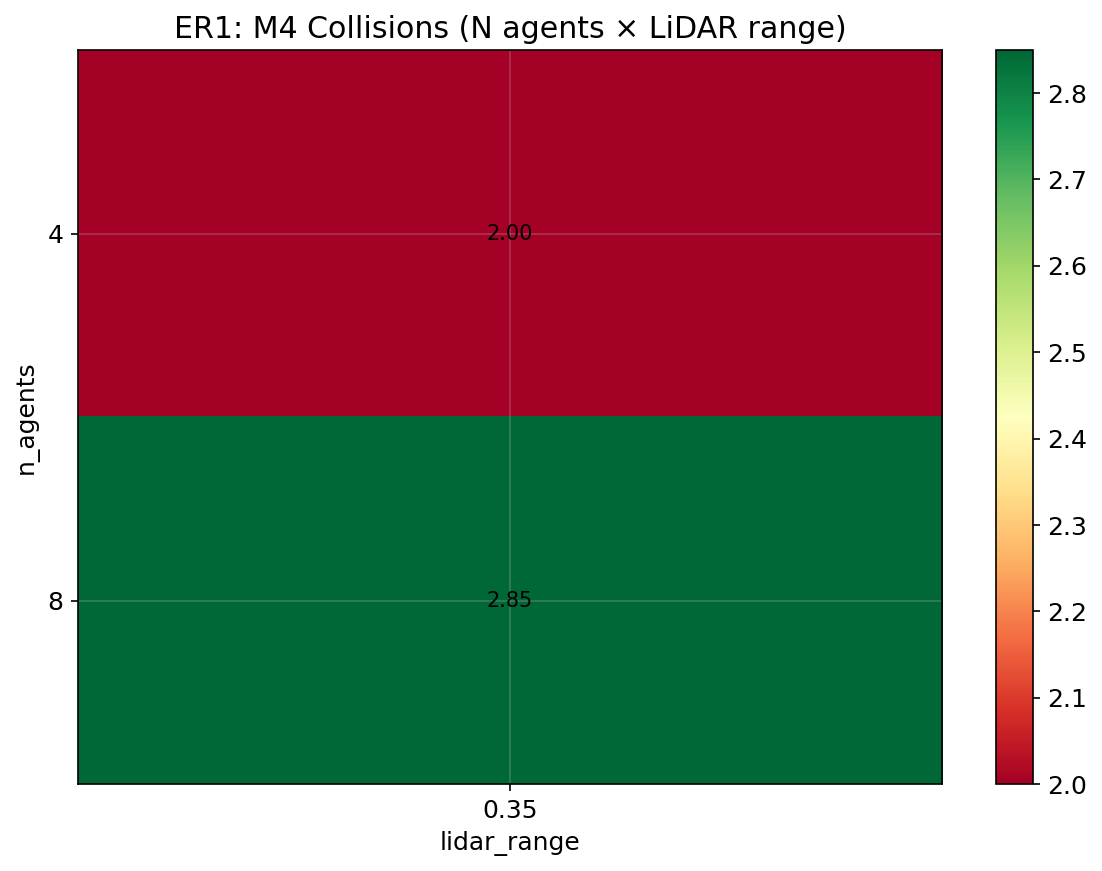

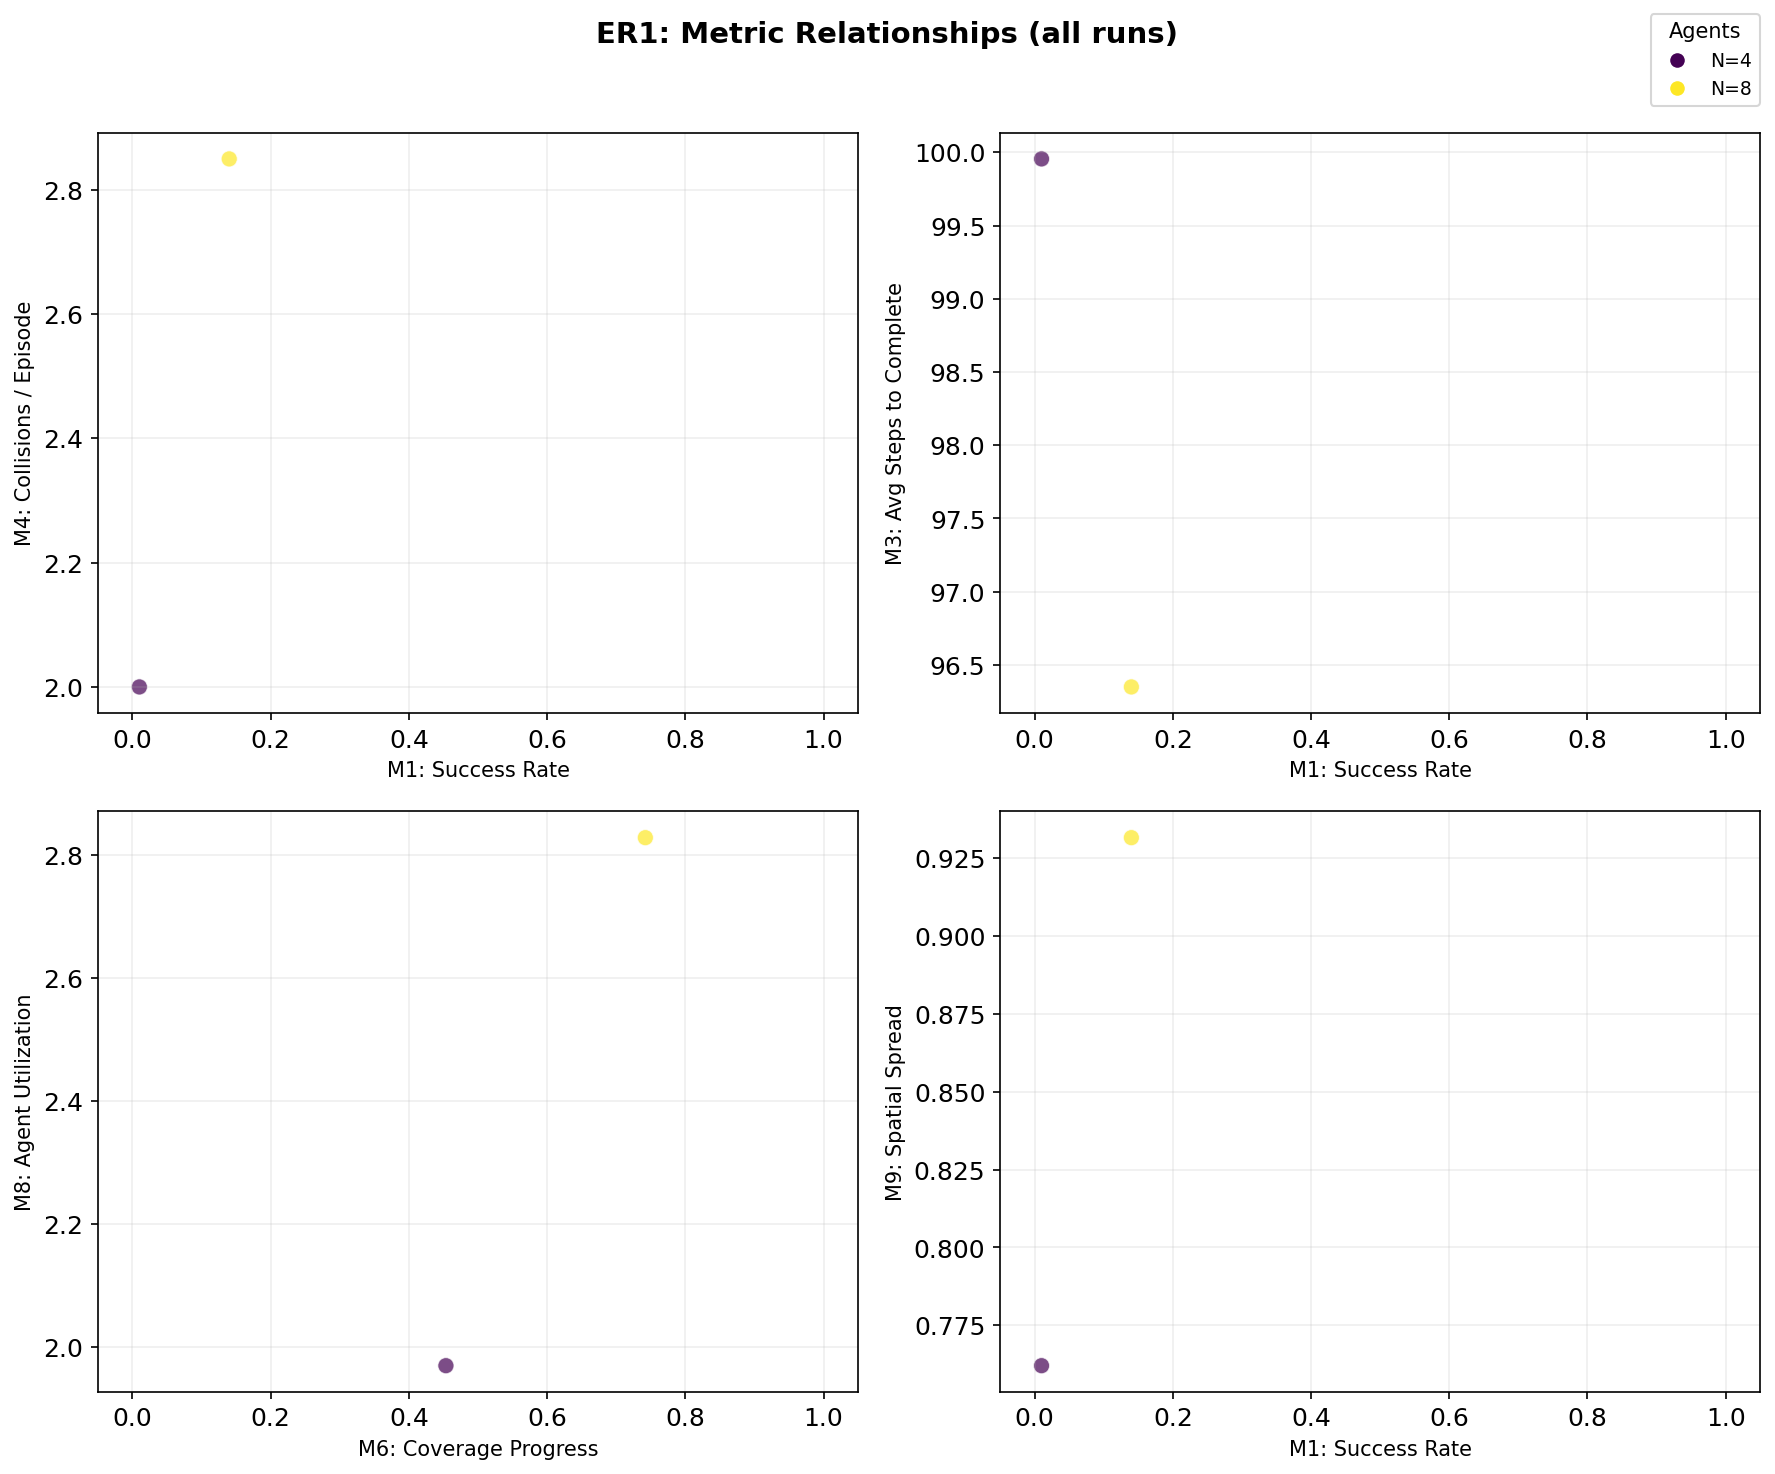

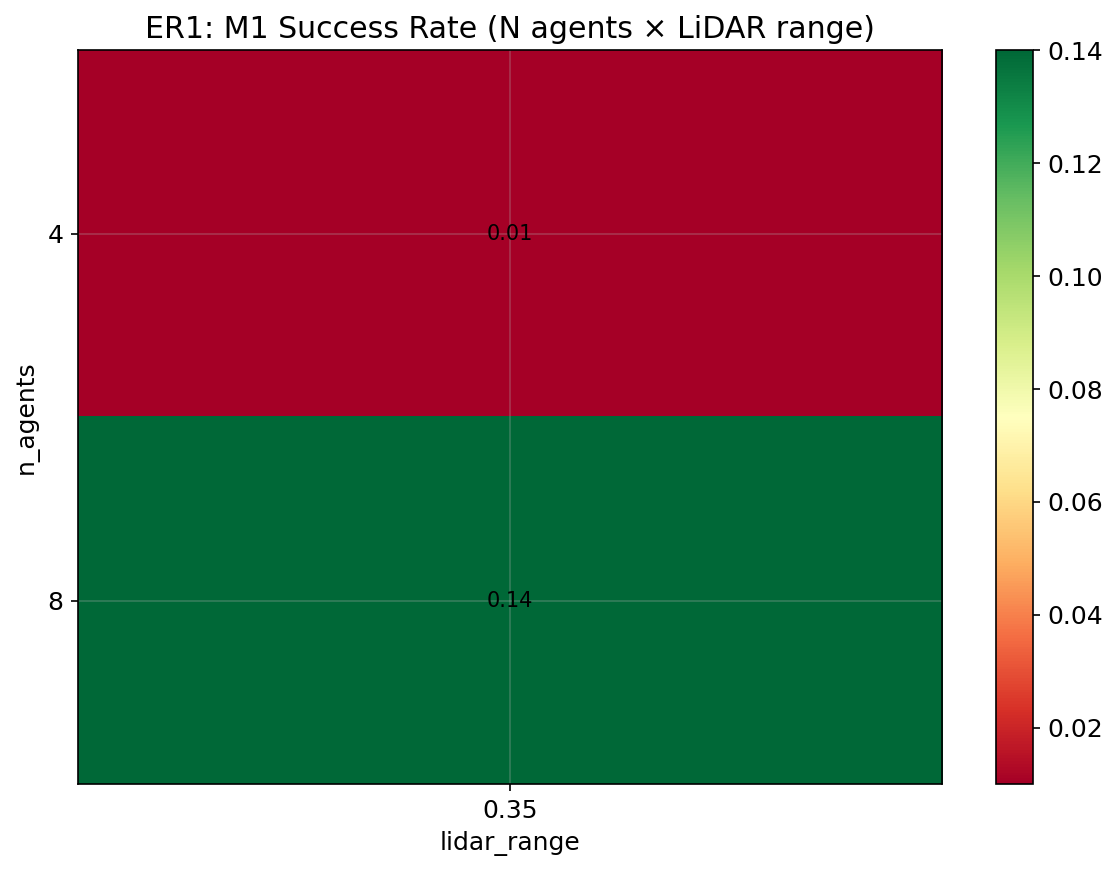

## Per-Run Results

| Run ID | M1: Success | M2: Return | M3: Steps | M4: Collisions | M6: Coverage | M8: Util | M9: Spread |
|--------|------------|--------|----------|---------------|------------|---------|-----------|
| `er1_mappo_n4_t4_k2_l035_s0` | 6.0% | -0.19 | 99 | 1.47 | 47.0% | 1.800 | 0.807 |

---
Each run folder contains its own `report.md` with full configuration, training stats, and artifacts.


# Experiment Report: ER1 — No-Comm Control

| | |
|---|---|
| **Run ID** | `er1_mappo_n4_t4_k2_l035_s0` |
| **Folder** | `20260312_1441__er1_mappo_n4_t4_k2_l035_s0` |
| **Generated** | 2026-03-12 15:47:48 |

> Isolates baseline task difficulty by removing ALL communication. Establishes the floor that any comm method must beat. Single config run for quick validation (~15 min on CPU).

## Task Configuration (Discovery Scenario)

| Parameter | Value | Description |
|-----------|-------|-------------|
| `n_agents` (N) | **4** ⚙ | Number of agents |
| `n_targets` (T) | **4** ⚙ | Number of targets to cover |
| `agents_per_target` (K) | **2** ⚙ | Agents required per target simultaneously |
| `covering_range` | **0.25** | Distance threshold to 'cover' a target |
| `lidar_range` | **0.35** ⚙ | LiDAR sensing range |
| `targets_respawn` | **False** | Must be False for M1/M3 |
| `max_steps` | **200** | Max steps per episode |

<details><summary>Other task parameters</summary>

| Parameter | Value |
|-----------|-------|
| `use_agent_lidar` | False |
| `n_lidar_rays_entities` | 15 |
| `n_lidar_rays_agents` | 12 |
| `shared_reward` | False |
| `agent_collision_penalty` | -0.1 |
| `covering_rew_coeff` | 1.0 |
| `time_penalty` | -0.01 |
| `x_semidim` | 1.0 |
| `y_semidim` | 1.0 |
| `min_dist_between_entities` | 0.2 |

⚙ = overridden by sweep
</details>

## Training Configuration

| Setting | Value |
|---------|-------|
| Algorithm | **MAPPO** |
| Total frames | 6,000,000 |
| Iterations | 100 |
| Frames/batch | 60,000 |
| Parallel envs | 60 |
| SGD epochs/batch | 45 |
| Minibatch size | 4,096 |
| Learning rate | 5e-05 |
| Gamma | 0.99 |
| Shared policy | True |
| Device | cpu |
| Eval interval | every 600,000 frames |
| Eval episodes | 50 |

## Training Summary

- **Wall time:** 1h 5m 52s
- **Throughput:** 1,518 frames/sec
- **Time/iteration:** 39.5s

## Evaluation Results

**200 episodes** — deterministic (no exploration)

| Metric | Value | Description |
|--------|-------|-------------|
| **M1: Success Rate** | 6.0% | Fraction of evaluation episodes where ALL targets were covered. A target is 'covered' when K agents are within covering_range simultaneously. Episode ends when every target has been covered. |
| **M2: Avg Return** | -0.1875 | Mean cumulative reward per episode (covering + collision penalty + time penalty). Positive = covering outweighs penalties. |
| **M3: Avg Steps to Completion** | 98.7 | Mean steps until all targets covered. Equals max_steps if episode never completes. Lower = faster. |
| **M4: Collisions/Episode** | 1.47 | Mean agent-agent collisions per episode. |
| **M5: Tokens/Episode** | 0.0 | Communication tokens per episode. Always 0 for no-comm baselines (ER1). |
| **M6: Coverage Progress** | 47.0% | Fraction of targets covered by episode end (partial credit). 100% = all targets covered in every episode. |
| **M8: Agent Utilization** | 1.800 | Coefficient of variation of per-agent covering counts. 0 = perfectly balanced workload. |
| **M9: Spatial Spread** | 0.807 | Mean pairwise agent distance. Higher = exploring, lower = clumping. Field diagonal ≈ 2.83. |

## Output Artifacts

📁 `/Users/afin/Documents/Studio/PHD/Code/VectorizedMultiAgentSimulator/rendezvous_comm/results/er1/20260312_1441__er1_mappo_n4_t4_k2_l035_s0`

| Path | Size | Description |
|------|------|-------------|
| `input/config.yaml` | 944 B | Frozen config snapshot |
| `logs/run.log` | 1.5 KB | Training log with timestamps |
| `output/metrics.json` | 286 B | Final evaluation metrics (M1–M9) |
| `output/policy.pt` | 291.5 KB | Trained policy weights |
| `output/benchmarl/` | (dir) | BenchMARL raw outputs |

## How to Reproduce / Reload

```python
from src.runner import build_experiment
from src.storage import ExperimentStorage
storage = ExperimentStorage('er1')
run = storage.get_run('er1_mappo_n4_t4_k2_l035_s0')
state_dict = run.load_policy_state_dict()
# Rebuild experiment with same config:
experiment = build_experiment(...)
experiment.policy.load_state_dict(state_dict)
```


In [13]:
from IPython.display import clear_output
clear_output(wait=True)

if all_metrics:
    from src.report import generate_sweep_report

    sweep_report = generate_sweep_report(spec, all_metrics)
    scrollable_md(sweep_report, height=500, title="Sweep Report (all runs)",
                  image_base=spec.results_dir)

    for run_id in sorted(all_metrics.keys()):
        rs = storage.get_run(run_id)
        report_path = rs.run_dir / "report.md"
        if report_path.exists():
            scrollable_md(report_path.read_text(), height=400,
                          title=f"Run Report — {run_id}",
                          image_base=rs.run_dir)

## Output Artifacts

Each run is self-contained in its timestamped folder. Browse the file tree and policy info below.

In [14]:
from IPython.display import clear_output
clear_output(wait=True)

if not all_metrics:
    print("No completed runs.")
else:
    for run_id in sorted(all_metrics.keys()):
        rs = storage.get_run(run_id)
        display_artifact_tree(rs)
        if rs.has_policy():
            sd = rs.load_policy_state_dict()
            if sd:
                total = sum(p.numel() for p in sd.values() if p is not None)
                print(f"  Policy: {len(sd)} tensors, {total:,} parameters")
                print(f"  File:   {rs.output_dir / 'policy.pt'}")
        print()

  Policy: 8 tensors, 71,941 parameters
  File:   /Users/afin/Documents/Studio/PHD/Code/VectorizedMultiAgentSimulator/rendezvous_comm/results/er1/20260312_1441__er1_mappo_n4_t4_k2_l035_s0/output/policy.pt

